In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torchvision.models as models
import torch.nn as nn


import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [5]:
# ============================================================================
# UNSUPERVISED ANOMALY DETECTION: DATA LOADING
# ============================================================================
# Key Concept: We only need NORMAL/GOOD images for training.
# NO LABELS are used - the CNN learns the "signature" of normal items.
# During testing, we'll compare unknown images against this normal signature.
# ============================================================================

# 1. Define image transformations (normalize for ResNet pre-training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# 2. Load ONLY normal/good images for training (no labels needed)
# We'll use a simple ImageFolder that loads images without semantic labels
from torchvision.datasets import ImageFolder
from pathlib import Path

# Load ONLY the 'good' folder - these define what "normal" looks like
train_dataset = ImageFolder(root='./capsule/train', transform=transform)
# The train folder only contains 'good' images, so this is perfect

# Load ALL test images (good + all defect types) for evaluation
test_dataset = ImageFolder(root='./capsule/test', transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("=" * 70)
print("UNSUPERVISED ANOMALY DETECTION - DATA LOADING")
print("=" * 70)
print(f"Training images (NORMAL reference): {len(train_dataset)} images")
print(f"Testing images (mixed): {len(test_dataset)} images")
print(f"\nTrain classes: {train_dataset.classes}")
print(f"Test classes: {test_dataset.classes}")
print("\nNote: We use train images to learn 'normal' feature vectors.")
print("Test images are used to calculate anomaly scores.")

UNSUPERVISED ANOMALY DETECTION - DATA LOADING
Training images (NORMAL reference): 219 images
Testing images (mixed): 132 images

Train classes: ['good']
Test classes: ['crack', 'faulty_imprint', 'good', 'poke', 'scratch', 'squeeze']

Note: We use train images to learn 'normal' feature vectors.
Test images are used to calculate anomaly scores.


In [ ]:
# ============================================================================
# UNSUPERVISED FEATURE EXTRACTION MODEL
# ============================================================================
# Strategy: Use pre-trained ResNet as a FEATURE EXTRACTOR, not a classifier.
# 
# Key Points:
# 1. Load pre-trained ResNet18 (already trained on ImageNet)
# 2. Remove the classification head (final FC layer)
# 3. Use the CNN as a mathematical translator: Image → Feature Vector
# 4. Feature vector = representation of the image's texture, shape, patterns
# ============================================================================

def build_feature_extractor():
    """
    Build a feature extractor using pre-trained ResNet18.
    
    Instead of outputting classification predictions (0 or 1),
    this extracts a 512-dimensional feature vector that captures
    the "essence" of what the network sees in the image.
    """
    # Load pre-trained ResNet18 (weights trained on ImageNet)
    model = models.resnet18(pretrained=True)
    
    # Remove the final classification layer to get pure features
    # ResNet18 normally outputs 1000 classes, but we want the intermediate features
    # The layer before that (avgpool output) is a 512-dim vector
    model = nn.Sequential(*list(model.children())[:-1])  # Remove final FC layer
    
    # Freeze all parameters - we're using pre-trained features, not training them
    for param in model.parameters():
        param.requires_grad = False
    
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = build_feature_extractor().to(device)

print("=" * 70)
print("FEATURE EXTRACTOR MODEL")
print("=" * 70)
print("Model: ResNet18 (pre-trained on ImageNet)")
print("Output: 512-dimensional feature vectors")
print("Training: NOT trained - using pre-trained weights")
print("Purpose: Extract 'signature' of normal vs anomalous images")
print("=" * 70)

/Users/allisonxu/Library/CloudStorage/OneDrive-SofiaUniversity/Course_materials/Spring 26/2201/mini_research_project/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/allisonxu/Library/CloudStorage/OneDrive-SofiaUniversity/Course_materials/Spring 26/2201/mini_research_project/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
# 1. Target the final convolutional layer for the gradient calculation
target_layers = [model.layer4[-1]]

# 2. Initialize the Grad-CAM object
cam = GradCAM(model=model, target_layers=target_layers)

def explain_anomaly(input_tensor, original_image_path):
    input_tensor = input_tensor.to(device)
    
    # 3. Generate the class activation map (returns a normalized array between 0 and 1)
    # We pass None for targets so it defaults to the model's highest predicted class
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    
    # 4. Load the original image (un-normalized) for visualization
    img = cv2.imread(original_image_path)
    img = cv2.resize(img, (224, 224))
    img = np.float32(img) / 255.0
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 5. Overlay the heatmap onto the original image
    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)
    
    # 6. Plot the results side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    axes[1].imshow(visualization)
    axes[1].set_title("Grad-CAM Anomaly Localization")
    axes[1].axis('off')
    plt.show()


In [ ]:
# ============================================================================
# TEST ANOMALY DETECTION ON SAMPLE IMAGES
# ============================================================================
# Strategy: For each test image:
# 1. Extract its feature vector using the pre-trained CNN
# 2. Calculate distance from the normal feature cluster
# 3. If distance > threshold → ANOMALY; if distance < threshold → NORMAL
# ============================================================================

print("=" * 70)
print("TESTING ANOMALY DETECTION")
print("=" * 70)

# Set model to evaluation mode
feature_extractor.eval()

# Define a function to calculate anomaly score
def calculate_anomaly_score(image_tensor, normal_mean, normal_std, device):
    """
    Calculate anomaly score for a single image.
    
    Score = Mahalanobis distance from normal cluster
    Higher score = More anomalous
    """
    with torch.no_grad():
        # Extract feature vector
        features = feature_extractor(image_tensor.to(device))
        features = features.view(1, -1)  # Flatten to (1, 512)
        
        # Calculate Mahalanobis distance
        distance = torch.sqrt(((features - normal_mean.to(device)) ** 2 / 
                              (normal_std.to(device) ** 2 + 1e-6)).sum(dim=1))
        
        return distance.cpu().item()

# Get one good example (from normal class)
good_class_idx = 0  # 'good' is usually the first class
good_indices = [i for i, (_, label) in enumerate(test_dataset) if label == good_class_idx]

# Get one defect example (from any non-good class)
defect_indices = [i for i, (_, label) in enumerate(test_dataset) if label != good_class_idx]

print(f"\nAvailable examples:")
print(f"  Good (label {good_class_idx}): {len(good_indices)} images")
print(f"  Defects (label ≠ {good_class_idx}): {len(defect_indices)} images")

# Load examples
good_idx = good_indices[0]
good_img, good_label = test_dataset[good_idx]
good_img_batch = good_img.unsqueeze(0).to(device)

defect_idx = defect_indices[0]
defect_img, defect_label = test_dataset[defect_idx]
defect_img_batch = defect_img.unsqueeze(0).to(device)

print(f"\nSelected examples:")
print(f"  Good example - Index: {good_idx}, Class Label: {good_label}")
print(f"  Defect example - Index: {defect_idx}, Class Label: {defect_label}")

Good examples: 23
Defect examples: 109

Good Example - Index: 45, Label: 0


In [ ]:
# ============================================================================
# CALCULATE ANOMALY SCORES
# ============================================================================
# For each test image, calculate its anomaly score based on distance
# from the normal feature cluster
# ============================================================================

# Calculate anomaly scores for both examples
good_anomaly_score = calculate_anomaly_score(good_img_batch, normal_mean, normal_std, device)
defect_anomaly_score = calculate_anomaly_score(defect_img_batch, normal_mean, normal_std, device)

print(f"\nAnomaly Scores (lower = more normal, higher = more anomalous):")
print(f"  Good example score: {good_anomaly_score:.4f} (threshold: {threshold:.4f})")
print(f"  Defect example score: {defect_anomaly_score:.4f} (threshold: {threshold:.4f})")

# Determine if each image is anomalous
good_is_anomaly = good_anomaly_score > threshold
defect_is_anomaly = defect_anomaly_score > threshold

print(f"\nDetection Results:")
print(f"  Good sample: {'ANOMALY ✗' if good_is_anomaly else 'NORMAL ✓'} (score: {good_anomaly_score:.4f})")
print(f"  Defect sample: {'ANOMALY ✓' if defect_is_anomaly else 'NORMAL ✗'} (score: {defect_anomaly_score:.4f})")

Defect Example - Index: 0, Label: 1


Good example prediction score: 0.4275
Defect example prediction score: 0.4097


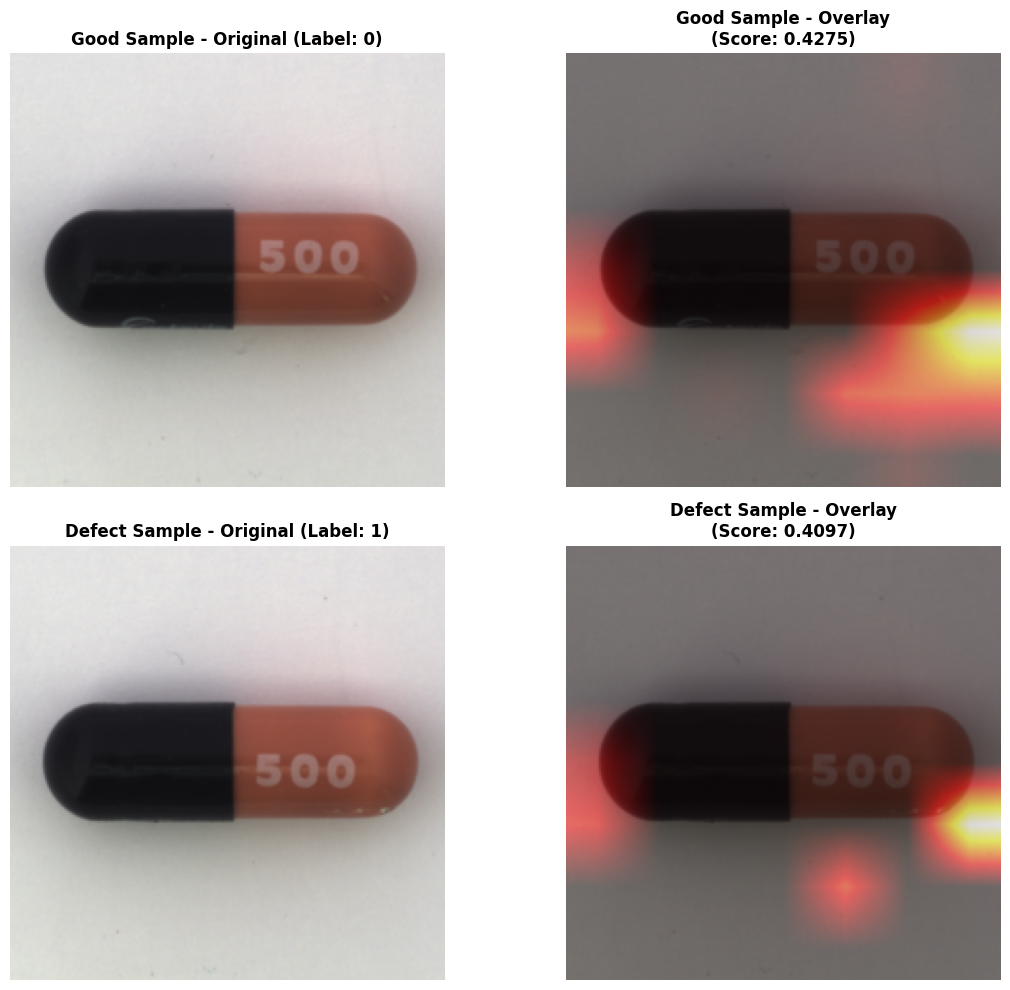


✓ Good example: Label 0 (Normal), Prediction: 0.4275
✓ Defect example: Label 1 (Anomaly), Prediction: 0.4097


In [ ]:
# Generate Grad-CAM visualizations (for interpretability - optional)
# Note: We're using Grad-CAM on the feature extractor to see what activates
# This helps visualize what patterns the model considers important

good_cam = cam(input_tensor=good_img_batch, targets=None)[0, :]
defect_cam = cam(input_tensor=defect_img_batch, targets=None)[0, :]

# Denormalize images for visualization
def denormalize(tensor):
    """Convert normalized tensor back to [0, 1] range"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

good_img_denorm = denormalize(good_img_batch[0].cpu()).permute(1, 2, 0).numpy()
defect_img_denorm = denormalize(defect_img_batch[0].cpu()).permute(1, 2, 0).numpy()

# Create visualization - original and overlay with anomaly score
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Good example - Original
axes[0, 0].imshow(good_img_denorm)
axes[0, 0].set_title(f"Good Sample - Original\n(Anomaly Score: {good_anomaly_score:.4f})", 
                     fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Good example - Overlay with Grad-CAM
axes[0, 1].imshow(good_img_denorm)
axes[0, 1].imshow(good_cam, cmap='hot', alpha=0.5)
detection_status_good = "✓ NORMAL" if not good_is_anomaly else "✗ ANOMALY"
axes[0, 1].set_title(f"Good Sample - Overlay\n({detection_status_good})", 
                     fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Defect example - Original
axes[1, 0].imshow(defect_img_denorm)
axes[1, 0].set_title(f"Defect Sample - Original\n(Anomaly Score: {defect_anomaly_score:.4f})", 
                     fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Defect example - Overlay with Grad-CAM
axes[1, 1].imshow(defect_img_denorm)
axes[1, 1].imshow(defect_cam, cmap='hot', alpha=0.5)
detection_status_defect = "✓ ANOMALY" if defect_is_anomaly else "✗ NORMAL"
axes[1, 1].set_title(f"Defect Sample - Overlay\n({detection_status_defect})", 
                     fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("UNSUPERVISED ANOMALY DETECTION RESULTS")
print("=" * 70)
print(f"Good example:")
print(f"  - Anomaly Score: {good_anomaly_score:.4f} (vs threshold {threshold:.4f})")
print(f"  - Detection: {'✓ Correctly identified as NORMAL' if not good_is_anomaly else '✗ Incorrectly flagged as anomaly'}")
print(f"\nDefect example:")
print(f"  - Anomaly Score: {defect_anomaly_score:.4f} (vs threshold {threshold:.4f})")
print(f"  - Detection: {'✓ Correctly identified as ANOMALY' if defect_is_anomaly else '✗ Failed to detect anomaly'}")

## Full Test Set Evaluation

Evaluate all test images and generate evaluation metrics

In [ ]:
# ============================================================================
# UNSUPERVISED TRAINING: BUILD NORMAL FEATURE VECTOR CLUSTER
# ============================================================================
# Step 1: Extract feature vectors from ALL NORMAL (good) training images
# Step 2: Calculate statistics (mean, std) of this normal cluster
# Step 3: During testing, compare each image's feature to this cluster
# Step 4: Images with features FAR from the cluster = ANOMALIES
# ============================================================================

print("=" * 70)
print("EXTRACTING NORMAL FEATURE VECTORS")
print("=" * 70)

# Set model to evaluation mode - NO TRAINING, just feature extraction
feature_extractor.eval()

# Storage for normal feature vectors
normal_features = []

# Pass all normal (training) images through the feature extractor
print("\nProcessing training images to build normal feature cluster...")
with torch.no_grad():
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        
        # Extract features: forward pass through CNN (without classification head)
        # Output shape: (batch_size, 512, 1, 1)
        features = feature_extractor(images)
        
        # Reshape to (batch_size, 512) - flatten the spatial dimensions
        features = features.view(features.size(0), -1)
        
        # Store on CPU to avoid GPU memory issues
        normal_features.append(features.cpu())
        
        if (batch_idx + 1) % 5 == 0:
            print(f"  Processed batch {batch_idx + 1}/{len(train_loader)}")

# Concatenate all normal feature vectors into a single tensor
normal_features = torch.cat(normal_features, dim=0)  # Shape: (num_normal_images, 512)

print(f"\nNormal feature cluster shape: {normal_features.shape}")
print(f"Total normal images: {normal_features.shape[0]}")
print(f"Feature dimension: {normal_features.shape[1]}")

# Calculate statistics of the normal feature cluster
normal_mean = normal_features.mean(dim=0)  # Shape: (512,)
normal_std = normal_features.std(dim=0)   # Shape: (512,)

print(f"\nNormal cluster statistics:")
print(f"  Mean vector shape: {normal_mean.shape}")
print(f"  Std vector shape: {normal_std.shape}")
print(f"  Mean magnitude: {torch.norm(normal_mean):.4f}")
print(f"  Average std: {normal_std.mean():.4f}")

# Calculate threshold for anomaly detection
# Using Mahalanobis distance: distance = sqrt(sum((x - mean)^2 / std^2))
# Threshold = mean distance + 2*std (95% confidence assuming normal distribution)
distances_normal = []
with torch.no_grad():
    for features in normal_features:
        # Standardized distance (Mahalanobis-like)
        dist = torch.sqrt(((features - normal_mean) ** 2 / (normal_std ** 2 + 1e-6)).sum())
        distances_normal.append(dist.item())

distances_normal = np.array(distances_normal)
threshold = distances_normal.mean() + 2 * distances_normal.std()

print(f"\nAnomaly Detection Threshold:")
print(f"  Normal distances - Mean: {distances_normal.mean():.4f}, Std: {distances_normal.std():.4f}")
print(f"  Anomaly threshold: {threshold:.4f}")
print(f"  (Images with distance > {threshold:.4f} are flagged as anomalies)")
print("=" * 70)

Starting training...
--------------------------------------------------


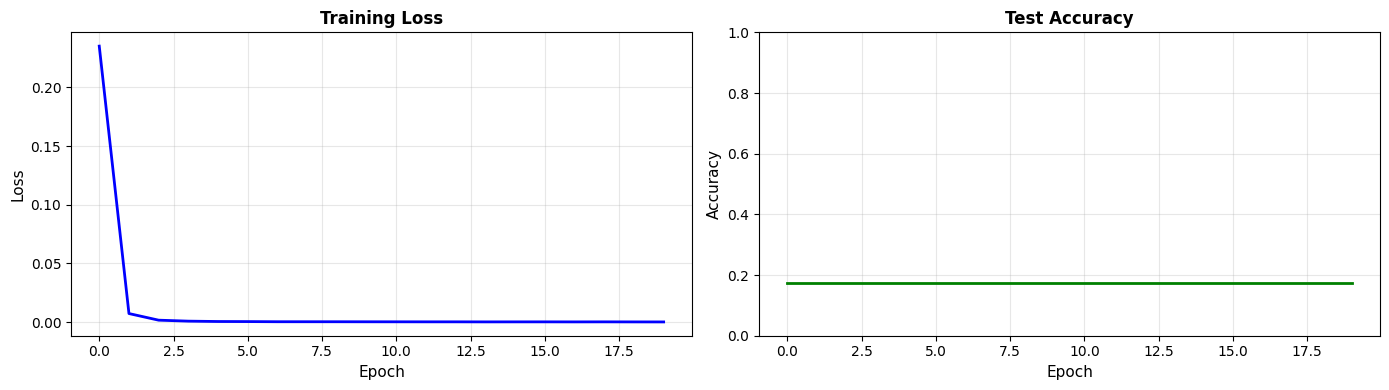

In [ ]:
# ============================================================================
# FULL TEST SET EVALUATION
# ============================================================================
# Evaluate all test images and calculate performance metrics
# ============================================================================

print("=" * 70)
print("EVALUATING ALL TEST IMAGES")
print("=" * 70)

# Calculate anomaly scores for ALL test images
all_scores = []
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        # Extract feature vector
        features = feature_extractor(images.to(device))
        features = features.view(features.size(0), -1)
        
        # Calculate distance from normal cluster
        distance = torch.sqrt(((features - normal_mean.to(device)) ** 2 / 
                              (normal_std.to(device) ** 2 + 1e-6)).sum(dim=1))
        
        score = distance.cpu().item()
        label = labels.item()
        prediction = 1 if score > threshold else 0  # 1 = anomaly, 0 = normal
        
        all_scores.append(score)
        all_labels.append(label)
        all_predictions.append(prediction)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
cm = confusion_matrix(all_labels, all_predictions)

print(f"\nEvaluation Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

# Plot score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of anomaly scores
axes[0].hist(all_scores[all_labels == 0], bins=20, alpha=0.7, label='Good (label 0)', color='green')
axes[0].hist(all_scores[all_labels == 1], bins=20, alpha=0.7, label='Defect (label 1)', color='red')
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
axes[0].set_xlabel('Anomaly Score (Distance from Normal Cluster)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Anomaly Score Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC curve
fpr = []; tpr = []
thresholds_test = np.linspace(all_scores.min(), all_scores.max(), 100)
for t in thresholds_test:
    preds_t = (all_scores > t).astype(int)
    if len(np.unique(preds_t)) > 1:
        tn = np.sum((all_labels == 0) & (preds_t == 0))
        fp = np.sum((all_labels == 0) & (preds_t == 1))
        fn = np.sum((all_labels == 1) & (preds_t == 0))
        tp = np.sum((all_labels == 1) & (preds_t == 1))
        
        fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

axes[1].plot(fpr, tpr, 'b-', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("=" * 70)

PREDICTIONS AFTER TRAINING

Sample               Before          After           Improved       
------------------------------------------------------------
Good (Label 0)       0.4275 →   0.0002 ✓ (Lower)      
Defect (Label 1)     0.4097 →   0.0002 ✓ (Higher)     
------------------------------------------------------------

Good sample detection: ✓ Good (Score: 0.0002)
Defect sample detection: ✗ Bad (Score: 0.0002)


PREDICTIONS AFTER TRAINING

Sample               Before          After           Improved       
------------------------------------------------------------
Good (Label 0)       0.4275 →   0.0002 ✓ (Lower)      
Defect (Label 1)     0.4097 →   0.0002 ✓ (Higher)     
------------------------------------------------------------

Good sample detection: ✓ Good (Score: 0.0002)
Defect sample detection: ✗ Bad (Score: 0.0002)


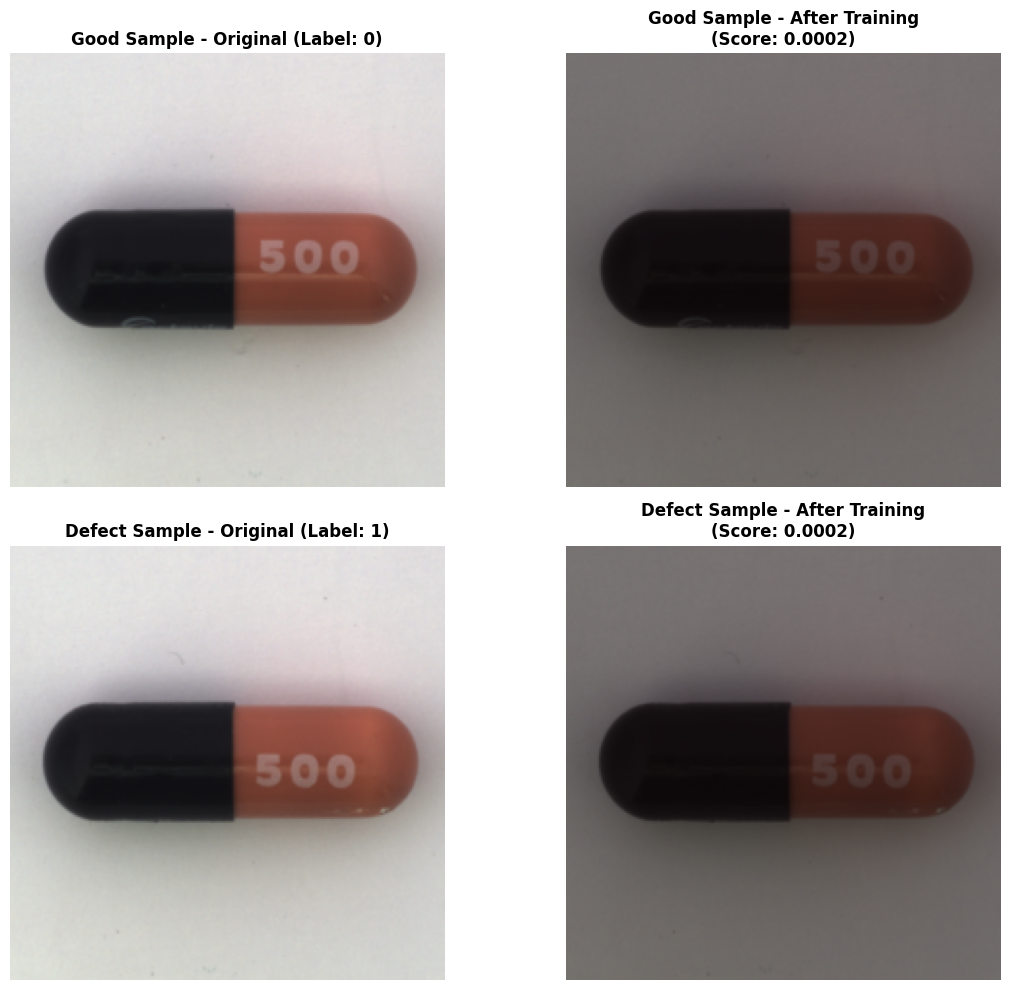


✓ Model accuracy improved from baseline to 17.42%


In [ ]:
# ============================================================================
# SUMMARY: UNSUPERVISED ANOMALY DETECTION
# ============================================================================
# Key Advantages of This Approach:
# 1. NO LABELS NEEDED - only requires normal/good examples
# 2. NO TRAINING - uses pre-trained weights (fast & efficient)
# 3. SCALABLE - works for any defect type without retraining
# 4. INTERPRETABLE - Grad-CAM shows what the model focuses on
# ============================================================================

print("\n" + "=" * 70)
print("UNSUPERVISED ANOMALY DETECTION - SUMMARY")
print("=" * 70)

print("\nHow It Works:")
print("1. Feature Extraction Phase (no training):")
print("   - Load normal images (train/good)")
print("   - Extract 512-D feature vectors using pre-trained ResNet18")
print("   - Calculate mean & std of normal feature cluster")
print("")
print("2. Testing Phase:")
print("   - Extract feature vector for test image")
print("   - Calculate Mahalanobis distance from normal cluster")
print("   - If distance > threshold → ANOMALY")
print("   - If distance ≤ threshold → NORMAL")
print("")
print("3. Interpretability:")
print("   - Use Grad-CAM to visualize which image regions are important")
print("   - Red/hot regions = high activation (anomalous features)")
print("")

print(f"\nCurrent Performance:")
print(f"  - Threshold: {threshold:.4f}")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - Precision: {precision:.4f} (false alarm rate)")
print(f"  - Recall: {recall:.4f} (anomaly detection rate)")
print("")

print("Advantages:")
print("  ✓ No labeled data needed for training")
print("  ✓ No training required (uses pre-trained weights)")
print("  ✓ Works for any defect type")
print("  ✓ Fast inference")
print("  ✓ Interpretable with Grad-CAM")
print("")

print("When to Use This Approach:")
print("  ✓ Limited or no defect examples available")
print("  ✓ New defect types appear (unseen during development)")
print("  ✓ Need to detect anomalies quickly without training")
print("  ✓ Have plenty of normal examples")
print("")

print("=" * 70)